**SVM** - это алгоритм классификации, который ищет гиперплоскость, максимально разделяющую классы. Идея в том, чтобы провести границу между классами так, чтобы расстояние до ближайших точек было максимальным. Эти ближайшие точки называются опорными векторами.

SVM ищет границу w*x+b=0 и максимизирует margin — расстояние между классами.

Если данные линейно неразделимы, используется kernel trick — перевод данных в пространство большей размерности.

**Плюсы**: хорошо работает на небольших и средних датасетах, может строить сложные границы и устойчив к переобучению.

**Минусы**: медленно обучается на больших данных, требует нормализации, чувствителен к выбору параметров.

In [2]:
# Блок с используемыми библиотеками
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/transactions_train.csv", sep=",")
df.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,359131,2023-01-01 00:02:00.328105993,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,...,desktop,0,0.142532,1,3,1,33.458018,2205.262235,0,0.099920
1,351207,2023-01-01 00:02:26.339769237,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,...,mobile,0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715
2,10209,2023-01-01 00:06:54.145825305,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,...,desktop,0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647
3,62660,2023-01-01 00:06:57.723185583,4041,2525,1914,1,1,2906.711704,0.202223,610.407487,...,mobile,0,0.171764,1,2,0,18.840187,513.517097,0,0.354154
4,384254,2023-01-01 00:08:05.487541188,3979,1555,360,2,3,5082.651983,0.171230,986.397163,...,mobile,0,0.248766,1,1,0,15.344375,816.975430,0,0.149084


In [4]:
# Блок с предварительной обработкой датасета

df.info()

# заменим время на категории день и ночь. Обычно день это 06:00 – 17:59, ночь: 18:00 – 05:59

df_dates = df.copy();
df_dates['transaction_time'] = pd.to_datetime(df['transaction_time'])

def is_night(t):
    hour = t.hour
    if 6 <= hour < 18:
        return False
    else:
        return True
        
df_dates['is_night'] = df_dates['transaction_time'].apply(is_night)

df_encoded = pd.get_dummies(df_dates, columns=['payment_channel', 'device_type'])

# заполнять нули тоже не нужно

df_transformed = df_encoded
df_transformed.info()

<class 'pandas.DataFrame'>
RangeIndex: 300113 entries, 0 to 300112
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   transaction_id                   300113 non-null  int64  
 1   transaction_time                 300113 non-null  str    
 2   customer_id                      300113 non-null  int64  
 3   merchant_id                      300113 non-null  int64  
 4   account_age_days                 300113 non-null  int64  
 5   credit_score_band                300113 non-null  int64  
 6   kyc_level                        300113 non-null  int64  
 7   avg_monthly_spend                300113 non-null  float64
 8   merchant_risk_score              300113 non-null  float64
 9   transaction_amount               300113 non-null  float64
 10  payment_channel                  300113 non-null  str    
 11  device_type                      300113 non-null  str    
 12  is_internatio

In [5]:
#Блок с обучением модели

# Признаки (X) и целевая переменная (y)

X = df_transformed.drop(['is_fraud', 'post_auth_risk_score', 'transaction_time'], axis=1)
y = df_transformed['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6769
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

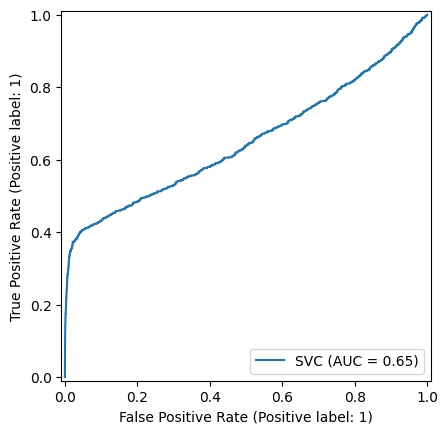

Accuracy: 0.9845392599503524
Precision: 0.9834919516005384
Recall: 0.9845392599503524
F1-score: 0.9770642889673831
[[59084     1]
 [  927    11]]


In [7]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print(cm)

In [13]:
model = SVC(kernel='rbf', C=20, gamma=0.001)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

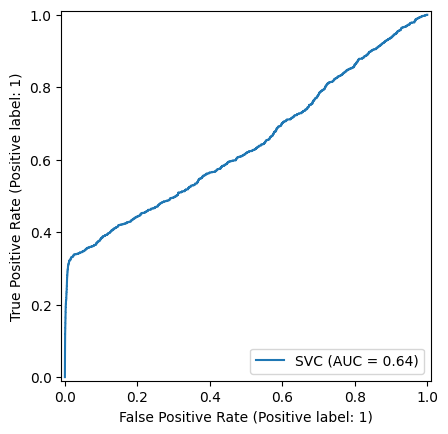

Accuracy: 0.9843726571480932
Precision: 0.9689895281407975
Recall: 0.9843726571480932
F1-score: 0.9766205199918576
[[59085     0]
 [  938     0]]


In [14]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print(cm)